## kmeans clustering implementation

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
x,y = make_blobs(n_samples=1000,centers=3,n_features=2)

In [3]:
x

array([[ 1.415707  , -7.01295018],
       [ 6.42479785,  1.46583277],
       [ 0.04438756,  6.02784161],
       ...,
       [-1.89580771,  3.35694346],
       [ 5.65207502,  2.88313508],
       [ 1.26052201, -5.74200748]], shape=(1000, 2))

In [4]:
y

array([2, 0, 1, 2, 1, 2, 2, 2, 0, 2, 2, 0, 0, 2, 2, 1, 1, 0, 1, 2, 0, 1,
       1, 1, 2, 0, 0, 0, 0, 0, 2, 0, 1, 0, 2, 2, 1, 2, 1, 2, 0, 2, 2, 1,
       2, 2, 1, 1, 0, 2, 0, 1, 0, 1, 2, 0, 2, 2, 1, 2, 0, 2, 1, 2, 2, 1,
       1, 0, 2, 0, 2, 1, 1, 1, 0, 1, 2, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 2, 0, 0, 1, 1, 2, 0, 0, 0, 1, 0, 1, 2, 0, 2, 0, 1, 2,
       1, 1, 0, 0, 2, 1, 1, 2, 2, 0, 2, 2, 1, 2, 0, 2, 2, 2, 1, 0, 1, 2,
       0, 0, 0, 0, 2, 2, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 2, 2, 2,
       0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 1, 0, 2, 0, 1, 0, 1, 2, 0, 1, 2,
       1, 1, 2, 0, 0, 1, 2, 2, 1, 1, 1, 2, 0, 0, 1, 0, 2, 2, 1, 0, 2, 0,
       1, 1, 0, 1, 0, 1, 0, 2, 2, 0, 2, 0, 0, 0, 1, 0, 0, 1, 2, 2, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 0, 0, 2, 2, 2, 2, 2,
       0, 0, 1, 2, 0, 0, 0, 2, 2, 0, 2, 0, 2, 0, 0, 2, 1, 2, 0, 0, 0, 0,
       0, 2, 1, 1, 2, 0, 0, 0, 1, 1, 2, 2, 0, 2, 1, 0, 1, 1, 2, 2, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 2, 1, 0, 1, 2, 2, 0,

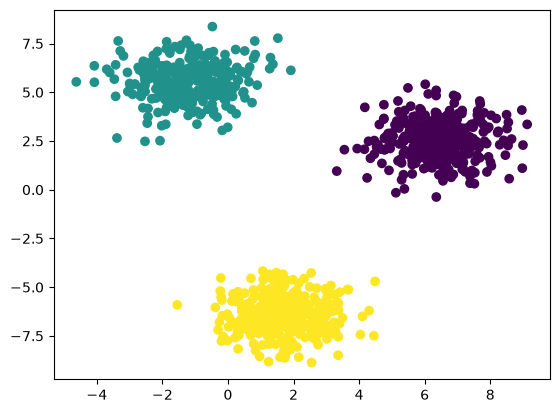

In [6]:
plt.scatter(x[:,0],x[:,1],c=y)

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [8]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [9]:
## scaled data
x_train_scaled = scaler.fit_transform(x_train)

In [10]:
x_test_scaled = scaler.transform(x_test)

In [11]:
from sklearn.cluster import KMeans

In [13]:
## find best k value using elbow methon using wcss

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(x_train_scaled)
    wcss.append(kmeans.inertia_)

In [14]:
wcss

[1400.0,
 752.502769682682,
 86.705471173086,
 74.4952685247634,
 60.60001114527506,
 58.08143378552339,
 44.77662071327566,
 40.81261164765455,
 37.00501865514073,
 33.96969999703471]

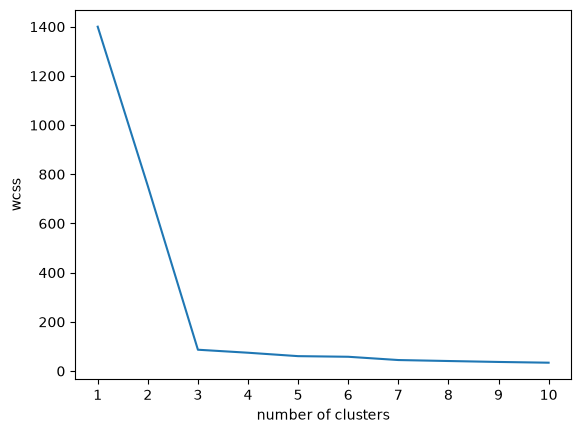

In [15]:
## plot the elbow curve

plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("number of clusters")
plt.ylabel("wcss")
plt.show()

In [17]:
kmeans = KMeans(n_clusters=3,init='k-means++')

In [18]:
kmeans.fit_predict(x_train_scaled)

array([2, 2, 1, 2, 0, 2, 0, 1, 2, 1, 0, 0, 1, 2, 0, 1, 1, 2, 2, 2, 2, 2,
       2, 0, 1, 2, 0, 2, 0, 1, 2, 2, 0, 0, 0, 1, 2, 0, 1, 2, 0, 2, 0, 0,
       1, 1, 2, 0, 1, 1, 2, 0, 0, 1, 1, 0, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1,
       0, 0, 0, 2, 2, 0, 1, 1, 0, 2, 1, 2, 0, 2, 0, 1, 1, 0, 2, 0, 2, 1,
       2, 0, 2, 0, 0, 2, 1, 0, 1, 0, 2, 2, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       0, 2, 1, 1, 2, 2, 0, 0, 0, 2, 2, 2, 0, 2, 2, 1, 2, 0, 0, 2, 1, 2,
       2, 0, 2, 1, 0, 2, 2, 0, 1, 2, 0, 0, 2, 2, 2, 2, 0, 0, 2, 0, 2, 0,
       1, 2, 2, 0, 2, 2, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0,
       1, 0, 1, 0, 2, 1, 1, 1, 2, 2, 0, 0, 0, 1, 1, 0, 2, 1, 1, 0, 1, 1,
       0, 0, 1, 2, 1, 2, 1, 1, 0, 0, 0, 0, 0, 2, 1, 2, 2, 1, 1, 1, 0, 2,
       0, 2, 0, 2, 2, 0, 0, 2, 0, 1, 2, 0, 1, 2, 1, 1, 0, 2, 0, 2, 1, 1,
       1, 1, 0, 2, 0, 2, 0, 0, 2, 1, 2, 0, 2, 0, 1, 0, 2, 1, 1, 0, 2, 2,
       1, 1, 2, 1, 2, 0, 1, 1, 2, 1, 0, 1, 1, 1, 2, 1, 1, 0, 0, 2, 2, 1,
       2, 0, 2, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2, 0, 1,

In [19]:
y_pred = kmeans.predict(x_test_scaled)

In [20]:
y_pred

array([0, 1, 2, 2, 2, 1, 2, 1, 1, 0, 1, 0, 0, 0, 2, 1, 2, 2, 0, 0, 1, 2,
       0, 2, 1, 1, 2, 0, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 0, 0, 1, 2, 1, 2,
       0, 0, 0, 2, 0, 1, 1, 0, 1, 1, 2, 0, 1, 0, 1, 2, 1, 0, 1, 1, 1, 2,
       2, 2, 0, 1, 1, 0, 2, 2, 1, 2, 1, 0, 1, 0, 0, 2, 0, 1, 2, 0, 1, 2,
       2, 1, 2, 0, 2, 1, 1, 0, 1, 2, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2, 1, 2,
       2, 0, 2, 2, 1, 1, 2, 0, 0, 0, 0, 2, 2, 1, 0, 2, 2, 2, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 2, 1, 2, 0, 1, 0, 2, 1, 2, 0, 2, 0, 1, 1, 1, 1, 2,
       2, 2, 2, 0, 1, 2, 0, 1, 2, 0, 2, 0, 0, 2, 2, 2, 0, 2, 2, 2, 0, 1,
       0, 0, 1, 2, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 2, 1, 2, 0, 0,
       1, 2, 1, 0, 2, 1, 2, 2, 2, 0, 2, 2, 2, 2, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 2, 0, 0, 2, 2, 0, 0, 0, 1, 2, 1, 1, 2, 1, 1, 0, 1, 0, 2, 0, 1,
       2, 2, 0, 0, 2, 2, 1, 1, 1, 2, 0, 2, 0, 2, 2, 1, 1, 0, 1, 1, 0, 2,
       1, 2, 0, 1, 2, 1, 2, 0, 0, 0, 2, 0, 0, 1, 1, 0, 2, 2, 0, 2, 1, 1,
       1, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0], d

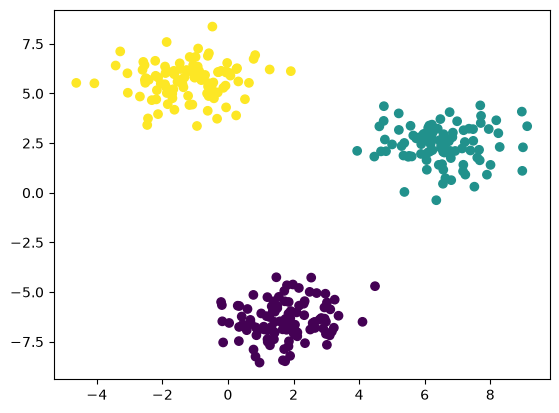

In [23]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_pred)